# 1. Data and architecture

This notebook introduces the normalized MNIST input, generates controlled
image corruption, and verifies the context-aware autoencoder's tensor flow.
It performs no expensive training and can be run independently.

In [1]:
import os
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter_runtime" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import torch

from src.config import ExperimentConfig
from src.data import create_mnist_loaders
from src.models import Autoencoder, count_parameters
from src.utils import add_noise, generate_context, seed_everything

config = ExperimentConfig()
seed_everything(config.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, test_loader = create_mnist_loaders(ROOT / "data", config.batch_size)
images, labels = next(iter(test_loader))
images = images.to(device)
print(f"Device: {device}")
print(f"Dataset sizes: train=60,000, test=10,000")
print(f"Image batch: {tuple(images.shape)}; value range: [{images.min():.1f}, {images.max():.1f}]")

Device: cpu
Dataset sizes: train=60,000, test=10,000
Image batch: (128, 1, 28, 28); value range: [-1.0, 1.0]


## Controlled corruption

MNIST is normalized to `[-1, 1]`. Gaussian noise makes the reconstruction
task ambiguous while preserving the original image as the learning target.

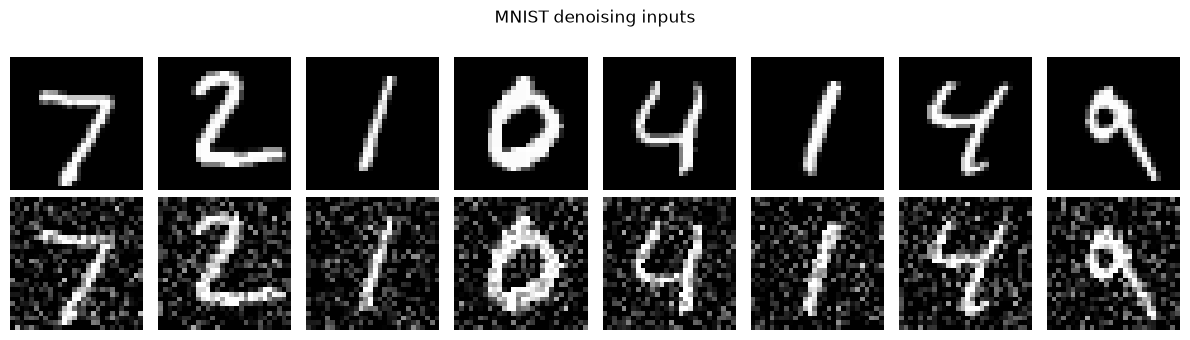

In [3]:
noisy = add_noise(images, noise_level=config.image_noise)
figure, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for column in range(8):
    for row, batch in enumerate((images, noisy)):
        axes[row, column].imshow(batch[column].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
        axes[row, column].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
figure.suptitle("MNIST denoising inputs")
figure.tight_layout()
plt.show()

## Context-conditioned model

The image pathway produces a latent representation. A linear projection of
the auxiliary context vector is added to it before decoding. Context therefore
changes reconstruction through the latent representation.

In [4]:
model = Autoencoder(config.capacity, config.latent_dims, config.context_dim).to(device)
context = generate_context(
    len(images), context_dim=config.context_dim,
    category_id=config.context_channel, device=device
)
with torch.inference_mode():
    latent = model.encoder(noisy, context)
    reconstructed = model.decoder(latent)
print(model)
print(f"Parameters: {count_parameters(model):,}")
print(f"Latent shape: {tuple(latent.shape)}")
print(f"Reconstruction shape: {tuple(reconstructed.shape)}")
assert reconstructed.shape == images.shape

Autoencoder(
  (encoder): Encoder(
    (conv1): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (fc1): Linear(in_features=1568, out_features=32, bias=True)
    (fc_context): Linear(in_features=10, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=1568, bias=True)
    (conv2): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv1): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  )
)
Parameters: 119,265
Latent shape: (128, 32)
Reconstruction shape: (128, 1, 28, 28)


**Interpretation.** Each 28×28 image is compressed to a 32-dimensional
vector and reconstructed to its original shape. At this point the network is
untrained; the next notebook learns the visual and contextual mappings.